In [1]:
import numpy as np
import pandas as pd
import requests

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Importing countries
url = "https://api.worldbank.org/countries?format=json&per_page=300"

response = requests.get(url)
response.status_code

200

In [3]:
data = response.json()
print(data[0])
print(len(data))
# 1 - Meta Data
# 2 - Countries Data(Actual Data)

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 296}
2


In [4]:
countries = data[1]
countries = pd.DataFrame(countries)
countries

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
...,...,...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
292,YEM,YE,"Yemen, Rep.","{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Sana'a,44.2075,15.352
293,ZAF,ZA,South Africa,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'UMC', 'iso2code': 'XT', 'value': 'Uppe...","{'id': 'IBD', 'iso2code': 'XF', 'value': 'IBRD'}",Pretoria,28.1871,-25.746
294,ZMB,ZM,Zambia,"{'id': 'SSF', 'iso2code': 'ZG', 'value': 'Sub-...","{'id': 'SSA', 'iso2code': 'ZF', 'value': 'Sub-...","{'id': 'LMC', 'iso2code': 'XN', 'value': 'Lowe...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Lusaka,28.2937,-15.3982


# Data Cleaning

In [5]:
countries["region"] = countries["region"].apply(lambda x: x["value"])
countries["incomeLevel"] = countries["incomeLevel"].apply(lambda x: x["value"])
countries["lendingType"] = countries["lendingType"].apply(lambda x: x["value"])
countries.drop(columns=["adminregion","capitalCity"], inplace = True)

In [6]:
countries

,id,iso2Code,name,region,incomeLevel,lendingType,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,Not classified,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,Aggregates,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,IBRD,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,IDA,28.2937,-15.3982


In [7]:
countries["region"].unique()

array(['Latin America & Caribbean ', 'Aggregates',
       'Middle East, North Africa, Afghanistan & Pakistan',
       'Sub-Saharan Africa ', 'Europe & Central Asia',
       'East Asia & Pacific', 'South Asia', 'North America'], dtype=object)

In [8]:
countries.rename(columns={"iso2Code" : "country_id"}, inplace = True)

In [9]:
countries[countries["region"]=="Aggregates"]

,id,country_id,name,region,incomeLevel,lendingType,longitude,latitude
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,Aggregates,,
3,AFR,A9,Africa,Aggregates,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,Aggregates,,
8,ARB,1A,Arab World,Aggregates,Aggregates,Aggregates,,
18,BEA,B4,East Asia & Pacific (IBRD-only countries),Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...
269,TSA,T5,South Asia (IDA & IBRD),Aggregates,Aggregates,Aggregates,,
270,TSS,T6,Sub-Saharan Africa (IDA & IBRD countries),Aggregates,Aggregates,Aggregates,,
278,UMC,XT,Upper middle income,Aggregates,Aggregates,Aggregates,,
288,WLD,1W,World,Aggregates,Aggregates,Aggregates,,


In [10]:
# Importing Indicators
base_url = "https://api.worldbank.org/v2/indicators?format=json"
response = requests.get(base_url)
response.status_code

200

In [11]:
indicators_data = response.json()
indicators_data[0]

{'page': 1, 'pages': 591, 'per_page': '50', 'total': 29511}

In [12]:
all_dfs = []
total_pages = indicators_data[0]["pages"]
for i in range(1, total_pages + 1):
    url = f"https://api.worldbank.org/v2/indicators?format=json&per_page=500&page={i}"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        indicators = data[1]
        if not indicators:
            print(f"No more data after page {i-1}")
            break
        df = pd.DataFrame([{"id":item["id"], "name":item["name"]} for item in indicators])
        all_dfs.append(df)
        print(f"Page {i}: {len(df)} indicators collected")
    else:
        print(f"Failed to fetch page {i}, status code {response.status_code()}")

Page 1: 500 indicators collected
Page 2: 500 indicators collected
Page 3: 500 indicators collected
Page 4: 500 indicators collected
Page 5: 500 indicators collected
Page 6: 500 indicators collected
Page 7: 500 indicators collected
Page 8: 500 indicators collected
Page 9: 500 indicators collected
Page 10: 500 indicators collected
Page 11: 500 indicators collected
Page 12: 500 indicators collected
Page 13: 500 indicators collected
Page 14: 500 indicators collected
Page 15: 500 indicators collected
Page 16: 500 indicators collected
Page 17: 500 indicators collected
Page 18: 500 indicators collected
Page 19: 500 indicators collected
Page 20: 500 indicators collected
Page 21: 500 indicators collected
Page 22: 500 indicators collected
Page 23: 500 indicators collected
Page 24: 500 indicators collected
Page 25: 500 indicators collected
Page 26: 500 indicators collected
Page 27: 500 indicators collected
Page 28: 500 indicators collected
Page 29: 500 indicators collected
Page 30: 500 indicators

In [13]:
final_df = pd.concat(all_dfs, ignore_index = True)
final_df

,id,name
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day)
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day)
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day)
...,...,...
29506,ytil_some_dfcl_all,Youth idle rate (% of persons with some degree...
29507,ytil_some_dfcl_fem,Youth idle rate (% of female persons with some...
29508,ytil_some_dfcl_male,Youth idle rate (% of male persons with some d...
29509,ytil_some_dfcl_rur,Youth idle rate (% of persons living in rural ...


In [14]:
final_df.to_csv("final_df.csv")

In [15]:
# Extraxt value for various indicators under the domain for each country

indicator_groups = {
    "economic_activity_growth" : [
        "NY.GDP.MKTP.KD.ZG", # GDP growth (annual %)
        "NY.GDP.PCAP.CD" # GDP per capita (constant 2015 US$)
    ],
    "labour_market_indicators" : [
        "SL.UEM.TOTL.ZS", # Unemployment, total (% of total labor force)
        "SL.UEM.1524.ZS", # Unemployment, youth total (% of total labor force ages 15-24)
        "SL.TLF.TOTL.IN" # Labor force, total
    ],
    "trade_global_indicators" : [
        "NE.EXP.GNFS.CD", # Exports of goods and services (current US$)
        "NE.IMP.GNFS.CD" # Imports of goods and services (current US$)
    ],
    "poverty_inequality" : [
        "SI.POV.NAHC", # Poverty headcount ratio at national poverty lines (% of population)
        "SI.POV.GINI" # Giniindex(measure of income inequality)
    ],
    "environmental_indicators" : [
        "EG.FEC.RNEW.ZS", # Renewable energy consumption (% of total final energy consumption)
        "AG.LND.FRST.ZS" # Forest area (% of land area)
    ],
    "health_indicators" : [
        "SP.DYN.LE00.IN", # Life expectancy at birth (years)
        "SP.DYN.IMRT.IN", # Infant mortality rate (per 1,000 live births)
        "SH.H2O.BASW.ZS", # Access to at least basic drinking water (% of population)
        "SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
        "SH.IMM.IDPT", # Immunization, DPT (% of children ages 12–23 months)
        "SH.IMM.MEAS", # Immunization, measles (% of children ages 12–23 months)
        "SH.MMR.RISK", # Risk of maternal death (lifetime risk)
        "SH.STA.BRTC.ZS", # Births attended by skilled health staff (% of total)
        "SH.STA.MMRT", # Maternal mortality ratio (modeled estimate, per 100,000 live births)
        "SH.DTH.COMM.ZS", # Deaths from communicable diseases (% of total deaths)
        "SH.TBS.INCD", # Tuberculosis incidence (per 100,000 people)
        "SH.HIV.INCD" # HIV incidence rate (per 1,000 uninfected population ages 15–49)
    ],
    "technology_indicators" : [
        "IT.NET.USER.ZS", # Individuals using the Internet (% of population)
        "IT.CEL.SETS.P2" # Mobile cellular subscriptions (per 100 people)
    ]
}


In [16]:
import time
base_url = "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"
category_dataframes = {}

for category, indicators in indicator_groups.items():
    print(f"Fetch information for category: {category}")
    all_dfs_for_category = []

    for indicator_code in indicators:
        print(f"Fetching indicator: {indicator_code}")
        page = 1

        while True:
            url = base_url.format(indicator_code,page)
            response = requests.get(url)
            if response.status_code != 200:
                print(f"No more data for indicator {indicator_code} on page{page}")
                break
                
            data = response.json()
            if not data or len(data)<2 or not data[1]:
                break

            record = data[1]
            df = pd.json_normalize(record)
            
            df= df[["country.id", "country.value", "indicator.id", "indicator.value", "date", "value"]].rename(columns={
                "country.id" : "country_id", 
                "country.value" : "country_value", 
                "indicator.id" : "indicator_id", 
                "indicator.value" : "indicator_name", 
                "date" : "year"})
            df = df[df["year"].notna()]
            df["year"] = df["year"].astype(int)
            df = df[df["year"] > 2015]
            
            if df.empty:
                print(f"No usable data after filtering at page {page}")
                break
            
            if not df.empty:
                df = df.dropna(how="all")
                if not df.empty:
                    all_dfs_for_category.append(df)
        
            page += 1
            time.sleep(0.3)

    if all_dfs_for_category:
        combined_df = pd.concat(all_dfs_for_category, ignore_index = True)
        category_dataframes[category] = combined_df
        print(f"Total rows collected for {category}: {len(combined_df)}") 
    else: 
        print(f"No data collected for {category}")
        
print("Data fetching completed")

Fetch information for category: economic_activity_growth
Fetching indicator: NY.GDP.MKTP.KD.ZG
Fetching indicator: NY.GDP.PCAP.CD
Total rows collected for economic_activity_growth: 5320
Fetch information for category: labour_market_indicators
Fetching indicator: SL.UEM.TOTL.ZS
Fetching indicator: SL.UEM.1524.ZS
Fetching indicator: SL.TLF.TOTL.IN
Total rows collected for labour_market_indicators: 7980
Fetch information for category: trade_global_indicators
Fetching indicator: NE.EXP.GNFS.CD
Fetching indicator: NE.IMP.GNFS.CD
Total rows collected for trade_global_indicators: 5320
Fetch information for category: poverty_inequality
Fetching indicator: SI.POV.NAHC
Fetching indicator: SI.POV.GINI
No more data for indicator SI.POV.GINI on page15
Total rows collected for poverty_inequality: 4788
Fetch information for category: environmental_indicators
Fetching indicator: EG.FEC.RNEW.ZS
Fetching indicator: AG.LND.FRST.ZS
Total rows collected for environmental_indicators: 5320
Fetch information 

In [17]:
category_dataframes

{'economic_activity_growth':      country_id                country_value       indicator_id  \
 0            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 1            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 2            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 3            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 4            ZH  Africa Eastern and Southern  NY.GDP.MKTP.KD.ZG   
 ...         ...                          ...                ...   
 5315         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5316         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5317         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5318         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 5319         ZW                     Zimbabwe     NY.GDP.PCAP.CD   
 
                     indicator_name  year        value  
 0            GDP growth (annual %)  2025          NaN  
 1            GDP growth (annual %)  202

In [18]:
economic_activity = category_dataframes.get("economic_activity_growth", pd.DataFrame())
labour_market_jobs = category_dataframes.get("labour_market_indicators", pd.DataFrame())
trade_globalization = category_dataframes.get("trade_global_indicators", pd.DataFrame())
poverty_inequality = category_dataframes.get("poverty_inequality", pd.DataFrame())
environmental_indicators = category_dataframes.get("environmental_indicators", pd.DataFrame())
health_indicators = category_dataframes.get("health_indicators", pd.DataFrame())
technology_indicators = category_dataframes.get("technology_indicators", pd.DataFrame())

In [19]:
economic = pd.merge(economic_activity, countries, on = "country_id", how = "inner")
labour_market = pd.merge(labour_market_jobs, countries, on = "country_id", how = "inner")
trade = pd.merge(trade_globalization, countries, on = "country_id", how = "inner")
poverty = pd.merge(poverty_inequality, countries, on = "country_id", how = "inner")
environment = pd.merge(environmental_indicators, countries, on = "country_id", how = "inner")
health = pd.merge(health_indicators, countries, on = "country_id", how = "inner")
technology = pd.merge(technology_indicators, countries, on = "country_id", how = "inner")

In [20]:
economic.drop(columns = ["indicator_id", "id", "name"], inplace = True)
labour_market.drop(columns = ["indicator_id", "id", "name"], inplace = True)
trade.drop(columns = ["indicator_id", "id", "name"], inplace = True)
poverty.drop(columns = ["indicator_id", "id", "name"], inplace = True)
environment.drop(columns = ["indicator_id", "id", "name"], inplace = True)
health.drop(columns = ["indicator_id", "id", "name"], inplace = True)
technology.drop(columns = ["indicator_id", "id", "name"], inplace = True)

In [24]:
health

,country_id,country_value,indicator_name,year,value,region,incomeLevel,lendingType,longitude,latitude
0,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2025,NaN,Aggregates,Aggregates,Aggregates,,
1,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2024,65.349930,Aggregates,Aggregates,Aggregates,,
2,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2023,65.146228,Aggregates,Aggregates,Aggregates,,
3,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2022,64.487152,Aggregates,Aggregates,Aggregates,,
4,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2021,62.979999,Aggregates,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...,...,...,...
31915,ZW,Zimbabwe,Adults (ages 15-49) newly infected with HIV,2020,13000.000000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
31916,ZW,Zimbabwe,Adults (ages 15-49) newly infected with HIV,2019,16000.000000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
31917,ZW,Zimbabwe,Adults (ages 15-49) newly infected with HIV,2018,19000.000000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312
31918,ZW,Zimbabwe,Adults (ages 15-49) newly infected with HIV,2017,24000.000000,Sub-Saharan Africa,Lower middle income,Blend,31.0672,-17.8312


In [25]:
df_wide = health.pivot(index = ["country_value","year"],
                             columns = "indicator_name",
                             values = "value"
                            )

In [26]:
df_wide

indicator_name      Adults (ages 15-49) newly infected with HIV  \
country_value year                                                
Afghanistan   2016                                        930.0   
              2017                                        980.0   
              2018                                       1000.0   
              2019                                       1100.0   
              2020                                       1200.0   
...                                                         ...   
Zimbabwe      2020                                      13000.0   
              2021                                      16000.0   
              2022                                      12000.0   
              2023                                      12000.0   
              2024                                      12000.0   

indicator_name      Births attended by skilled health staff (% of total)  \
country_value year                                                         
Afghanistan   2016                                                NaN      
              2017                                               53.4      
              2018                                               58.8      
              2019                                                NaN      
              2020                                               61.8      
...                                                               ...      
Zimbabwe      2020                                                NaN      
              2021                                                NaN      
              2022                                                NaN      
              2023                                                NaN      
              2024                                                NaN      

indicator_name      Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
country_value year                                                                                                          
Afghanistan   2016                                                NaN                                                       
              2017                                                NaN                                                       
              2018                                                NaN                                                       
              2019                                          34.699979                                                       
              2020                                          39.274016                                                       
...                                                               ...                                                       
Zimbabwe      2020                                          47.059892                                                       
              2021                                          49.366899                                                       
              2022                                                NaN                                                       
              2023                                                NaN                                                       
              2024                                                NaN                                                       

indicator_name      Current health expenditure (% of GDP)  \
country_value year                                          
Afghanistan   2016                              11.818590   
              2017                              12.620817   
              2018                              14.208419   
              2019                              14.831320   
              2020                              15.533614   
...                                                   ...   
Zimbabwe      2020       

In [29]:
df_wide.corr()

indicator_name,Adults (ages 15-49) newly infected with HIV,Births attended by skilled health staff (% of total),"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",Current health expenditure (% of GDP),"Immunization, DPT (% of children ages 12-23 months)","Immunization, measles (% of children ages 12-23 months)","Incidence of tuberculosis (per 100,000 people)","Life expectancy at birth, total (years)",Lifetime risk of maternal death (1 in: rate varies by country),"Maternal mortality ratio (modeled estimate, per 100,000 live births)","Mortality rate, infant (per 1,000 live births)",People using at least basic drinking water services (% of population)
indicator_name,,,,,,,,,,,,
Adults (ages 15-49) newly infected with HIV,1.000000,-0.076034,0.028182,0.098510,-0.023164,-0.017056,0.083242,-0.030512,-0.073793,0.045522,0.057806,-0.019276
Births attended by skilled health staff (% of total),-0.076034,1.000000,-0.779022,0.296179,0.628646,0.651280,-0.522778,0.703002,0.297976,-0.795429,-0.803650,0.782594
"Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",0.028182,-0.779022,1.000000,-0.308631,-0.563859,-0.594946,0.570336,-0.855428,-0.416137,0.789824,0.851077,-0.806296
Current health expenditure (% of GDP),0.098510,0.296179,-0.308631,1.000000,0.211718,0.209458,-0.105569,0.295974,0.228047,-0.190509,-0.296384,0.292251
"Immunization, DPT (% of children ages 12-23 months)",-0.023164,0.628646,-0.563859,0.211718,1.000000,0.889053,-0.375677,0.591636,0.295398,-0.610197,-0.609512,0.578539
"Immunization, measles (% of children ages 12-23 months)",-0.017056,0.651280,-0.594946,0.209458,0.889053,1.000000,-0.370680,0.609014,0.274617,-0.636931,-0.626253,0.618626
"Incidence of tuberculosis (per 100,000 people)",0.083242,-0.522778,0.570336,-0.105569,-0.375677,-0.370680,1.000000,-0.603925,-0.316012,0.438485,0.570564,-0.529883
"Life expectancy at birth, total (years)",-0.030512,0.703002,-0.855428,0.295974,0.591636,0.609014,-0.603925,1.000000,0.497120,-0.832696,-0.909708,0.802273
Lifetime risk of maternal death (1 in: rate varies by country),-0.073793,0.297976,-0.416137,0.228047,0.295398,0.274617,-0.316012,0.497120,1.000000,-0.342552,-0.434635,0.355409


In [30]:
corr = df_wide.corr()

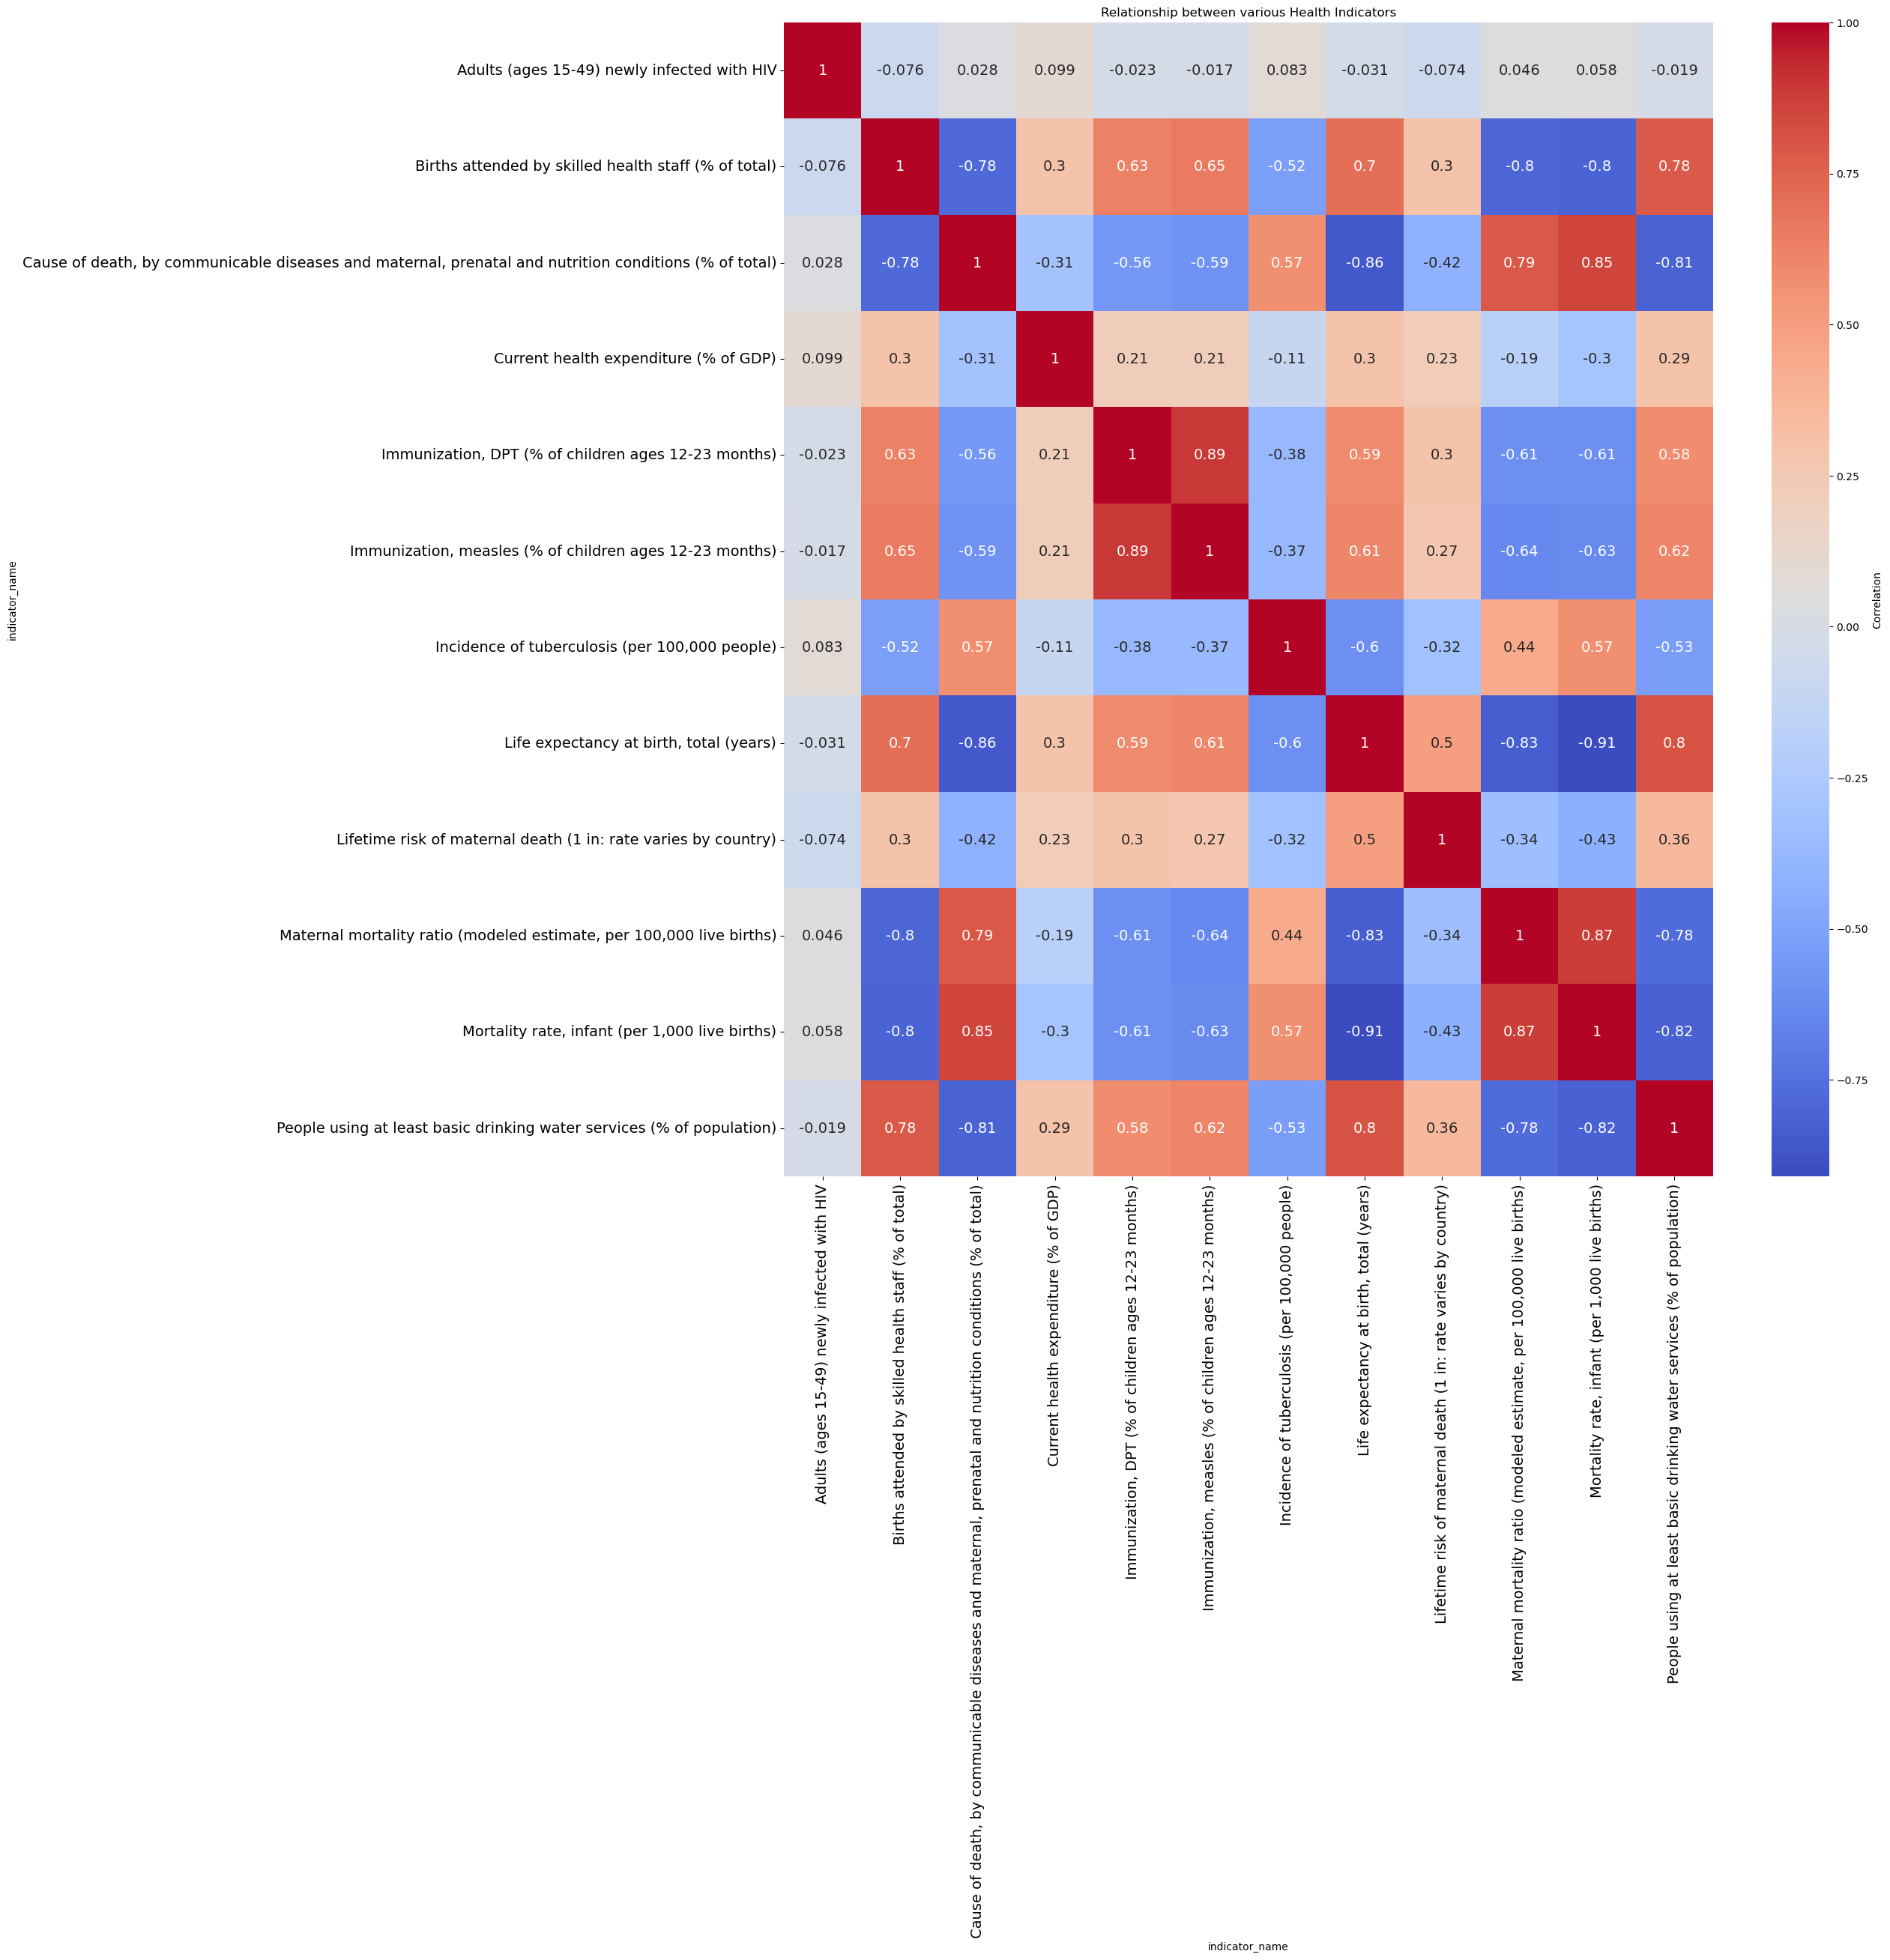

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
ax = sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    cbar_kws = {"label":"Correlation"},
    annot_kws = {"fontsize":14, "fontweight":14},
)
plt.title("Relationship between various Health Indicators")

ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.show()

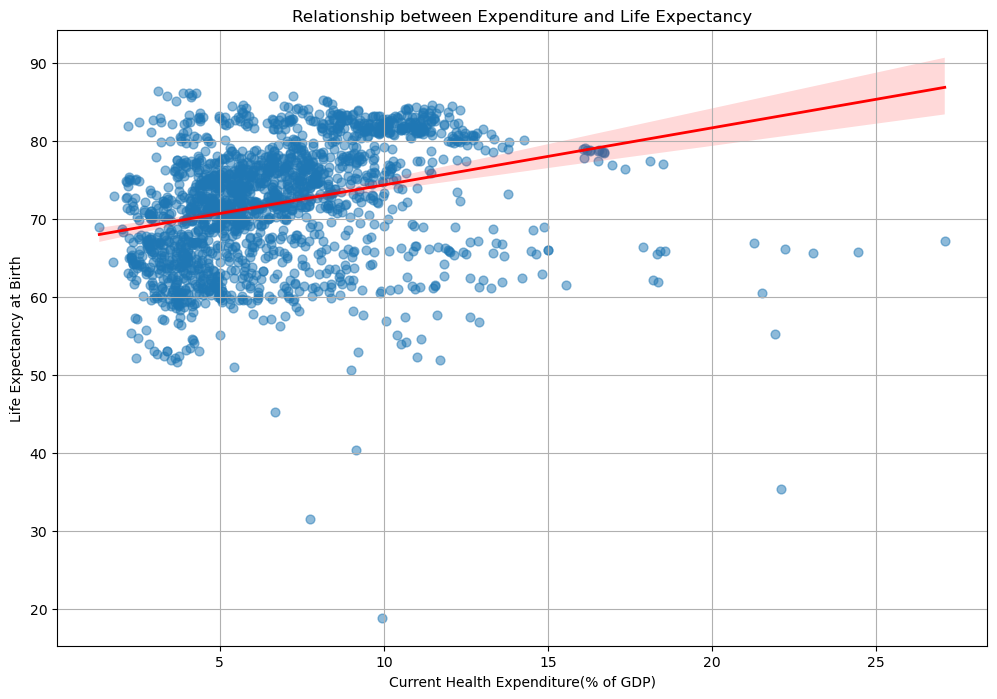

In [39]:
df_pivot = health.pivot(
    index = ["country_value","year"],
    columns = "indicator_name",
    values = "value"
)

plt.figure(figsize=(12,8), facecolor="none")
ax = sns.regplot(data = df_pivot,
                 x="Current health expenditure (% of GDP)",
                 y="Life expectancy at birth, total (years)",
                 scatter_kws = {"alpha":0.5, "s":40},
                 line_kws = {"color":"red","lw":2}
                )
plt.title("Relationship between Expenditure and Life Expectancy")
plt.xlabel("Current Health Expenditure(% of GDP)")
plt.ylabel("Life Expectancy at Birth")
plt.grid(True) 
plt.show()